# Dataset Splitting Paradigm

The goal here would be to split a dataset into train, dev and test subset such that all 3 classes have overlapping terms but also terms unique to each of the classes, in order to mimic an accurate and complete learning process.

In [120]:
import pandas as pd
import datasets
import matplotlib.pyplot as plt
import numpy as np

## Dataset Analysis

In [121]:
df = pd.read_json('data/divan10_final_data.jsonl', lines=True)
df.head()

,input,output
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը: type of inscription
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր: type of inscription
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից: type of inscription
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները: type of inscription
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր: type of inscription


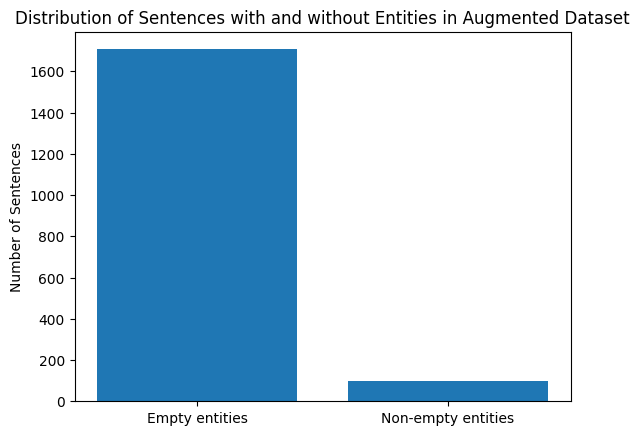

In [122]:
df_balance = df.copy()
df_balance['output'] = df_balance['output'].replace('', pd.NA)

plt.bar(
    x=['Empty entities', 'Non-empty entities'],
    height=[
        df_balance['output'].isna().sum(),
        (~df_balance['output'].isna()).sum()
    ]
)
plt.ylabel('Number of Sentences')
plt.title('Distribution of Sentences with and without Entities in Augmented Dataset')
plt.show()

## IOB Formatting

In [123]:
df['output'] = df['output'].apply(lambda x: x.split(':')[0] if ':' in str(x) else None)
df.rename(columns={'input':'sentence','output':'term'},inplace=True)
df['word'] = df['sentence'].apply(lambda x: str(x).split())    
df_exploded = df.explode('word')
df_exploded

,sentence,term,word
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ընդունելով
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ձեռագրում
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,տվյալ
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,միավորի
...,...,...,...
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,է
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,հայկարլի
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,սպը
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,տպարանում


In [124]:
def tag_logic(reference_terms,word):
    if not reference_terms or pd.isna(reference_terms):
        return 'O'
    if word in reference_terms.split():
        if word == reference_terms.split()[0]:
            return 'B-INSC'
        else:
            return 'I-INSC'
    else:
        return 'O'


In [125]:
df_exploded['tag'] = df_exploded.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
df_exploded

,sentence,term,word,tag
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ընդունելով,O
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ձեռագրում,O
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,տվյալ,O
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,միավորի,O
...,...,...,...,...
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,է,O
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,հայկարլի,O
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,սպը,O
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,տպարանում,O


In [126]:
df_exploded['word_labels'] = df_exploded[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
df_exploded

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ընդունելով,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,ձեռագրում,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,տվյալ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,միավորի,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
...,...,...,...,...,...
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,է,O,"O,O,O,O,O,O"
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,հայկարլի,O,"O,O,O,O,O,O"
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,սպը,O,"O,O,O,O,O,O"
1803,տպագրված է հայկարլի սպը տպարանում հեռ,None,տպարանում,O,"O,O,O,O,O,O"


In [127]:
df_exploded.drop_duplicates(subset=['sentence'], inplace=True)

In [128]:
df_exploded.head()

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."


## EDA

In [129]:
# Count total and unique terms
total_terms = len(df_exploded['term'])
unique_terms = df_exploded['term'].nunique()

# Nicely formatted output
print(f"Total number of terms: {total_terms:,}")
print(f"Number of unique terms: {unique_terms:,}")
print(f"Ratio of unique terms: {unique_terms / total_terms:.2%}")

Total number of terms: 1,730
Number of unique terms: 35
Ratio of unique terms: 2.02%


In [130]:
print("Top 10 most frequent terms:")
print(df_exploded['term'].value_counts().head(10))

Top 10 most frequent terms:
term
վիմագրերը    10
վիմագիրը     10
Վիմագիր      10
վիմագրում     8
տապանագիր     7
վիմագրի       5
վիմագրեր      4
խաչքար        3
նվիրագիր      3
վիմագիրն      2
Name: count, dtype: int64


* epitaphs 10
* epitaph 10
* epitaph 10
* epitaph 8
* epitaph 7
* epitaph 5
* epitaphs 4
* khachkar 3
* nvirgigrip 3
* epitaph 2

In [131]:
df_exploded['term'].unique()

array(['վիմագրերը', 'Վիմագիր', 'վիմագրերից',
       'վիմական արձանագրությունները', 'վիմագիր', 'վիմագիրը', 'խաչքար',
       'վիմագրում', 'վիմագրերում', 'հարկ', 'վիմագրությունները',
       'տապանագիր', 'Տապանագիր', 'նվիրատվական', 'վիմագրահավաքը',
       'վիմագրերի', 'նվիրագիր', 'տապանագրի', 'տապանագրեր', 'վիմագիրն',
       'վիմագրեր', 'վիմագրի', 'շինարարական արձանագրությունը',
       'փակագիր արձանագրություն', 'Շինարարական արձանագրություն',
       'տապանագրից', 'վիմագրերով', 'ապահարկություն', 'վիմագրությունը',
       'Նվիրատվական արձանագրություն', 'բարավորի արձանագրության',
       'տապանագիրը', 'տապանագրերը', 'տապանագիրն',
       'վիմական արձանագրություն', None], dtype=object)

```epithets', 'Epithet', 'from epithets',
'epithets', 'epithet', 'epithet', 'cross-stone',
'epithet', 'in epithets', 'tax', 'epithets',
'coffin', 'Coffin', 'donation', 'collection of epithets',
'epithets', 'donation', 'coffin', 'coffin', 'epithet',
'epithets', 'consecration', 'coffin', 'epithet',
'epithets', 'consecration', 'construction protocol',
'closed protocol', 'Construction protocol',
'from epithet', 'with epithets', 'reservation', 'epithet',
'Donation protocol', 'benefactor's protocol',
'coffin', 'coffin', 'coffin',
'stone inscription', None```

## Overlapping Split

In [132]:
import pandas as pd
import random
import seaborn as sns

def split_jsonl_dataset(df, train_frac=0.8, eval_frac=0.1, test_frac=0.1, random_state=42):
    """
    Splits a JSONL NER dataset into train/eval/test sets while holding out terms.
    """
    
    # 3 Split terms into train/eval/test
    all_terms = df['term'].dropna().unique().tolist()
    random.seed(random_state)
    random.shuffle(all_terms)
    
    n_terms = len(all_terms)
    n_train = int(train_frac * n_terms)
    n_eval  = int(eval_frac * n_terms)
    
    train_terms = all_terms[:n_train]
    eval_terms  = all_terms[n_train:n_train+n_eval]
    test_terms  = all_terms[n_train+n_eval:]
    
    # 4️ Assign samples based on term membership
    train_df = df[df['term'].isin(train_terms)].copy()
    eval_df  = df[df['term'].isin(eval_terms)].copy()
    test_df  = df[df['term'].isin(test_terms)].copy()
    
    # 5 Add remaining no-entity samples proportionally
    no_entity_df = df[df['term'].isna()]
    n_total = len(no_entity_df)
    n_train_noentity = int(train_frac * n_total)
    n_eval_noentity  = int(eval_frac * n_total)
    
    no_entity_df = no_entity_df.sample(frac=1, random_state=random_state)
    train_df = pd.concat([train_df, no_entity_df.iloc[:n_train_noentity]])
    eval_df  = pd.concat([eval_df,  no_entity_df.iloc[n_train_noentity:n_train_noentity+n_eval_noentity]])
    test_df  = pd.concat([test_df,  no_entity_df.iloc[n_train_noentity+n_eval_noentity:]])
    
    # 6️ Shuffle splits
    train_df = train_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    eval_df  = eval_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    test_df  = test_df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    
    return train_df, eval_df, test_df


def plot_term_distribution(train_df, eval_df, test_df, top_n=20):
    """
    Plots the distribution of terms across train/eval/test splits.
    """
    # Add set labels
    train_df_plot = train_df[['term']].copy()
    train_df_plot['set'] = 'train'
    eval_df_plot  = eval_df[['term']].copy()
    eval_df_plot['set'] = 'eval'
    test_df_plot  = test_df[['term']].copy()
    test_df_plot['set'] = 'test'
    
    plot_df = pd.concat([train_df_plot, eval_df_plot, test_df_plot], ignore_index=True)
    concat_df = plot_df.copy()
    plot_df = plot_df.dropna(subset=['term'])
    
    # Keep top N terms by total count
    top_terms = plot_df['term'].value_counts().head(top_n).index
    plot_df = plot_df[plot_df['term'].isin(top_terms)]
    
    plt.figure(figsize=(12,6))
    sns.countplot(data=plot_df, x='term', hue='set')
    plt.xticks(rotation=90)
    plt.title(f"Distribution of Top {top_n} Terms Across Train/Eval/Test")
    plt.xlabel("Term")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    return concat_df


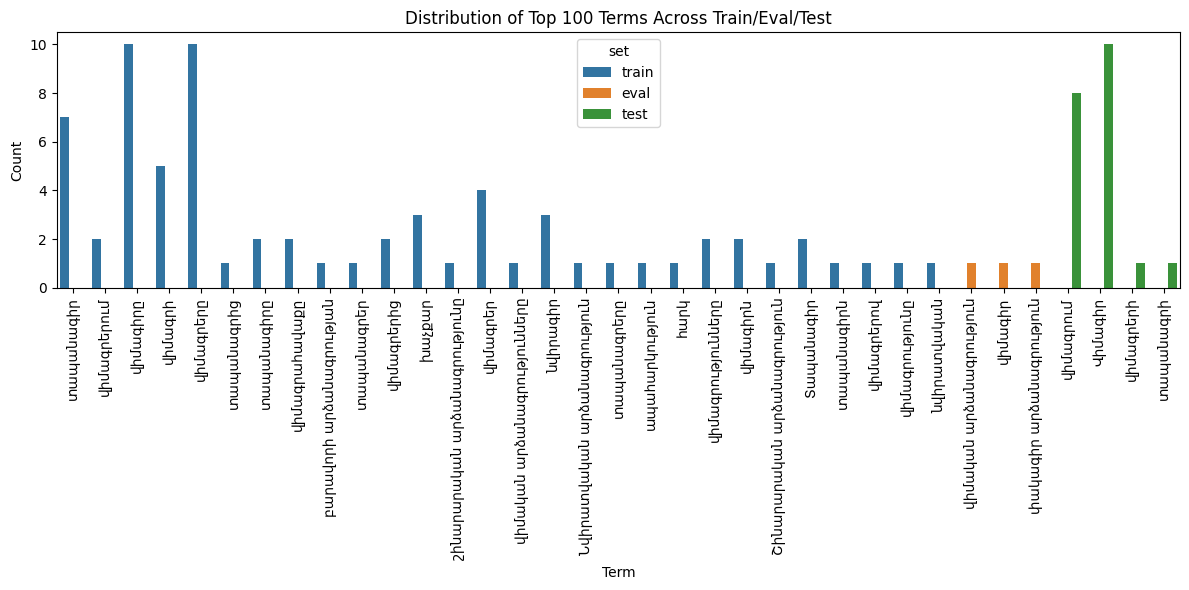

In [133]:
train_df, eval_df, test_df = split_jsonl_dataset(df_exploded)
dataset = plot_term_distribution(train_df, eval_df, test_df, top_n=100)

## Non-random Train Dev Test Split

In [134]:
df_exploded.term.unique()

array(['վիմագրերը', 'Վիմագիր', 'վիմագրերից',
       'վիմական արձանագրությունները', 'վիմագիր', 'վիմագիրը', 'խաչքար',
       'վիմագրում', 'վիմագրերում', 'հարկ', 'վիմագրությունները',
       'տապանագիր', 'Տապանագիր', 'նվիրատվական', 'վիմագրահավաքը',
       'վիմագրերի', 'նվիրագիր', 'տապանագրի', 'տապանագրեր', 'վիմագիրն',
       'վիմագրեր', 'վիմագրի', 'շինարարական արձանագրությունը',
       'փակագիր արձանագրություն', 'Շինարարական արձանագրություն',
       'տապանագրից', 'վիմագրերով', 'ապահարկություն', 'վիմագրությունը',
       'Նվիրատվական արձանագրություն', 'բարավորի արձանագրության',
       'տապանագիրը', 'տապանագրերը', 'տապանագիրն',
       'վիմական արձանագրություն', None], dtype=object)

In [135]:
testing_terms = ['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
                 'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն', 'ապահարկություն']

```
'khachkar', 'tax', 'coffin', 'coffin', 'donation',
'construction protocol', 'Construction protocol', 'reservation'
```

In [175]:
testing_positives = df_exploded[df_exploded['term'].isin(testing_terms)].reset_index(drop=True)
testing_positives.head()

,sentence,term,word,tag,word_labels
0,վլանէս թրտաշվլանէս խաչքար է կանգնեցրել,խաչքար,վլանէս,O,"O,O,B-INSC,O,O,O,O,O,O,O"
1,սմբատ նահնշահ ովհաննես սմբատ հայոց թագավոր թթ ...,հարկ,սմբատ,O,"O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O..."
2,սարգիս ձորավորաց եկեղեցու վանահայր խաչքարէ կան...,խաչքար,սարգիս,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
3,մարմաշեն հյ գերեզմանոց տապանագիր,տապանագիր,մարմաշեն,O,"O,O,O,B-INSC"
4,սարմաշեն գլխավոր տաճար հվ պատ արտ ոդ նվիրատվակ...,տապանագիր,սարմաշեն,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-INSC"


In [176]:
training_positives = df_exploded[
    df_exploded['term'].notna() & ~df_exploded['term'].isin(testing_terms)
].reset_index(drop=True)

training_positives.head()

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."


In [177]:
training_positives.term.unique()

array(['վիմագրերը', 'Վիմագիր', 'վիմագրերից',
       'վիմական արձանագրությունները', 'վիմագիր', 'վիմագիրը', 'վիմագրում',
       'վիմագրերում', 'վիմագրությունները', 'վիմագրահավաքը', 'վիմագրերի',
       'նվիրագիր', 'տապանագրի', 'տապանագրեր', 'վիմագիրն', 'վիմագրեր',
       'վիմագրի', 'փակագիր արձանագրություն', 'տապանագրից', 'վիմագրերով',
       'վիմագրությունը', 'Նվիրատվական արձանագրություն',
       'բարավորի արձանագրության', 'տապանագիրը', 'տապանագրերը',
       'տապանագիրն', 'վիմական արձանագրություն'], dtype=object)

In [139]:
eval_terms = ['փակագիր արձանագրություն','վիմագրահավաքը','տապանագրերը','Նվիրատվական արձանագրություն',
              'տապանագիրն','վիմագիր','վիմագրերը']

eval_positives = training_positives[training_positives['term'].isin(eval_terms)].reset_index(drop=True)
training_positives = training_positives[~training_positives['term'].isin(eval_terms)].reset_index(drop=True)

In [178]:
eval_positives.head()

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."
2,մեզ անհայտ պատճառով մարմաշենի վանքի և ձերծակայ...,վիմագրերը,մեզ,O,"O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O..."
3,ծանոթ օրբելին ինչպես և մենք այս և հաջորդ վիմագ...,վիմագրերը,ծանոթ,O,"O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O"
4,այդ վիմագրերը վերջերս հրատարակվեցին մատենադարա...,վիմագրերը,այդ,O,"O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O"


In [180]:
eval_positives.term.unique()

array(['վիմագրերը', 'վիմագիր', 'վիմագրահավաքը', 'փակագիր արձանագրություն',
       'Նվիրատվական արձանագրություն', 'տապանագրերը', 'տապանագիրն'],
      dtype=object)

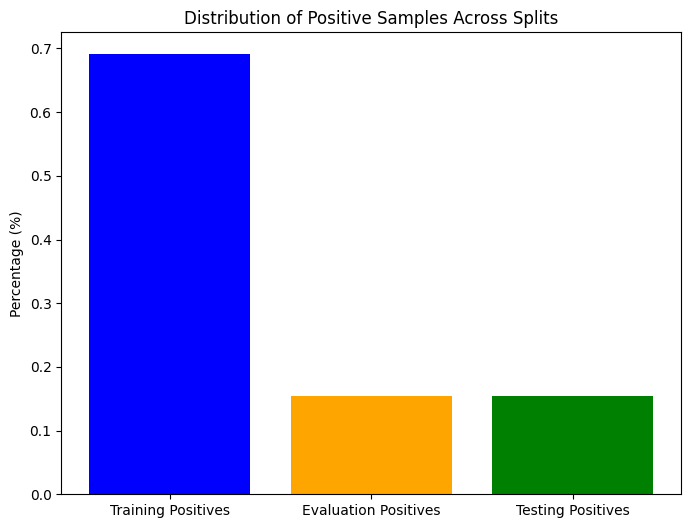

In [181]:
total_len = len(training_positives) + len(eval_positives) + len(testing_positives)

relative_len=[len(training_positives)/total_len, len(eval_positives)/total_len, len(testing_positives)/total_len]
labels = ['Training Positives', 'Evaluation Positives', 'Testing Positives']
plt.figure(figsize=(8,6))
plt.bar(labels, relative_len, color=['blue', 'orange', 'green'])
plt.ylabel('Percentage (%)')
plt.title('Distribution of Positive Samples Across Splits')
plt.show()

In [182]:
no_entity_df = df_exploded[df_exploded['term'].isna()]
n_total = len(no_entity_df)
n_train_noentity = int((len(training_positives)/total_len) * n_total)
n_eval_noentity  = int((len(eval_positives)/total_len) * n_total)

train_df_doctored = pd.concat([training_positives, no_entity_df.iloc[:n_train_noentity]])
eval_df_doctored  = pd.concat([eval_positives, no_entity_df.iloc[n_train_noentity:n_train_noentity+n_eval_noentity]])
test_df_doctored  = pd.concat([testing_positives, no_entity_df.iloc[n_train_noentity+n_eval_noentity:]])

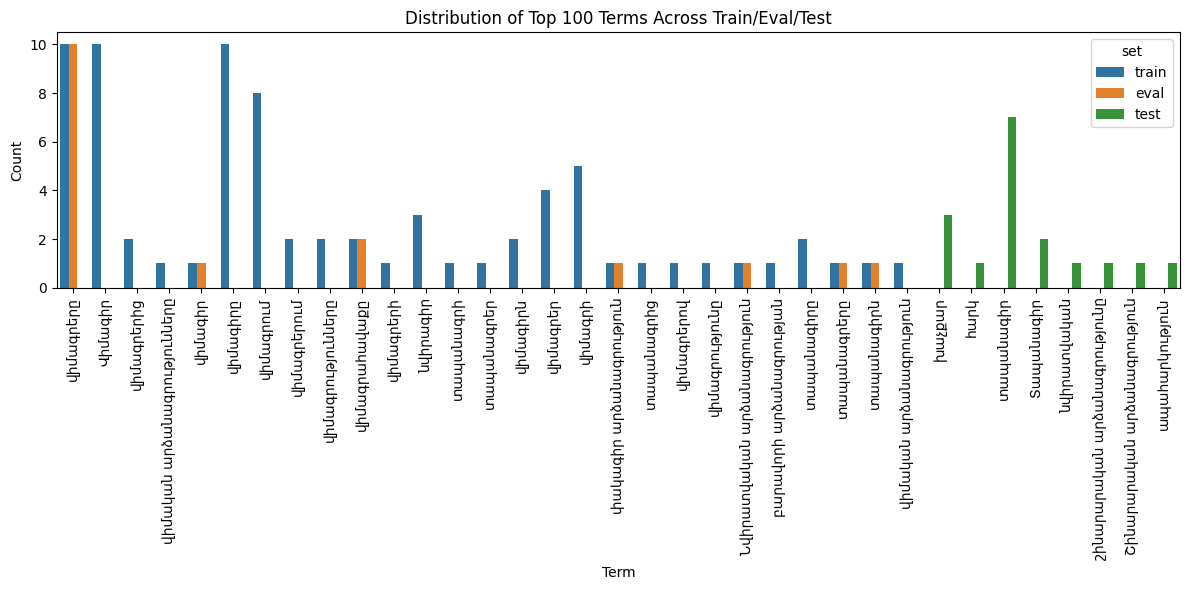

,term,set
0,վիմագրերը,train
1,Վիմագիր,train
2,վիմագրերից,train
3,վիմական արձանագրությունները,train
4,վիմագիր,train
...,...,...
1742,None,test
1743,None,test
1744,None,test
1745,None,test


In [183]:
plot_term_distribution(train_df_doctored, eval_df_doctored, test_df_doctored, top_n=100)

In [184]:
train_df_doctored.term.unique()

array(['վիմագրերը', 'Վիմագիր', 'վիմագրերից',
       'վիմական արձանագրությունները', 'վիմագիր', 'վիմագիրը', 'վիմագրում',
       'վիմագրերում', 'վիմագրությունները', 'վիմագրահավաքը', 'վիմագրերի',
       'նվիրագիր', 'տապանագրի', 'տապանագրեր', 'վիմագիրն', 'վիմագրեր',
       'վիմագրի', 'փակագիր արձանագրություն', 'տապանագրից', 'վիմագրերով',
       'վիմագրությունը', 'Նվիրատվական արձանագրություն',
       'բարավորի արձանագրության', 'տապանագիրը', 'տապանագրերը',
       'տապանագիրն', 'վիմական արձանագրություն', None], dtype=object)

In [185]:
eval_df_doctored.term.unique()

array(['վիմագրերը', 'վիմագիր', 'վիմագրահավաքը', 'փակագիր արձանագրություն',
       'Նվիրատվական արձանագրություն', 'տապանագրերը', 'տապանագիրն', None],
      dtype=object)

In [186]:
test_df_doctored.term.unique()

array(['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
       'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն',
       'ապահարկություն', None], dtype=object)

In [188]:
train_df_doctored.to_csv('data/train_ner_doctored.csv', index=False)
eval_df_doctored.to_csv('data/eval_ner_doctored.csv', index=False)
test_df_doctored.to_csv('data/test_ner_doctored.csv', index=False)

#### Graphing attempt

In [189]:
from huggingface_hub import login
HUGGINGFACE_TOKEN = "X"
login(token = HUGGINGFACE_TOKEN)

In [191]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("Metric-AI/armenian-text-embeddings-1")
model = AutoModel.from_pretrained("Metric-AI/armenian-text-embeddings-1")

In [150]:
terms = df_exploded.term.unique().tolist()
terms = ["query: "+term for term in terms if term is not None ]


In [151]:
import torch.nn.functional as F
from torch import Tensor

def average_pool(last_hidden_states: Tensor,
                 attention_mask: Tensor) -> Tensor:
    last_hidden = last_hidden_states.masked_fill(~attention_mask[..., None].bool(), 0.0)
    return last_hidden.sum(dim=1) / attention_mask.sum(dim=1)[..., None]

In [152]:
batch = tokenizer(terms, padding=True, truncation=True, return_tensors='pt')
outputs = model(**batch)
term_embeddings = average_pool(outputs.last_hidden_state, batch['attention_mask'])
term_embeddings = F.normalize(term_embeddings, p=2, dim=1)


In [153]:
import torch

similarity = term_embeddings @ term_embeddings.T
distance = 1 - similarity


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


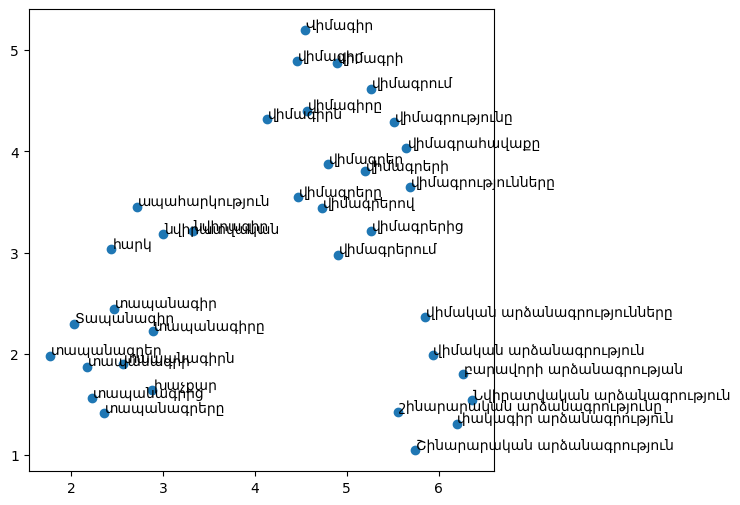

In [154]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

X_np = term_embeddings.detach().cpu().numpy()

reducer = umap.UMAP(metric='cosine', random_state=42)
emb_2d = reducer.fit_transform(X_np)

# 7. Plot
plt.figure(figsize=(6,6))
plt.scatter(emb_2d[:,0], emb_2d[:,1])
for i, term in enumerate(terms):
    plt.text(emb_2d[i,0]+0.01, emb_2d[i,1]+0.01, term.replace("query: ", ""), fontsize=10)
plt.show()


## Saving Dataframes for Reproducibility

In [155]:
train_df.to_csv('data/train_ner.csv',index=False)
eval_df.to_csv('data/eval_ner.csv',index=False)
test_df.to_csv('data/test_ner.csv',index=False)

# Augmented Dataset

### Data Augmentation

In [156]:
AUGMENT = False

In [157]:
from pydantic import BaseModel,Field
from typing import Optional,List
import openai
import os
from openai import OpenAI

if AUGMENT:
    openai.api_key = os.environ['OPENAI_API_KEY']
    client = OpenAI()
    types_of_inscriptions = pd.read_csv('data/types_of_inscriptions.csv')
    print(types_of_inscriptions.head())
    terms_list = types_of_inscriptions.to_dict(orient="records")

class WordOfInterest(BaseModel):
    input: str = Field(None, description="Sentence containing word of interest")
    output: str= Field(None, description="word of interest : type of inscription")

class AugmentedData(BaseModel):
    sentences: List[WordOfInterest]

def augmenting_prompting(examples,terms):
    augmented_prompt = f"""You are an expert in the Armenian Language and Epigraphy. 
    Your task is to generate around at least 500 sentences in armenian containing the following terms of interest: {', '.join([term['Term'] for term in terms])}.
    The task at hand is to augment a dataset wih examples of sentences containing these words of interest.
    
    The original dataset is given below:
    {examples}

    There are around 3500 sentences that do not contain any of the words of interest.
    Your task is to balance the dataset by generating new sentences that include the words of interest.
    
    Please generate the sentences in the following JSON format:
    {{
        "terms": [
            {{
                "input": "Sentence containing word of interest",
                "output": "word of interest : type of inscription"
            }},
            ...
        ]
    }}
    
    Proceed in the following way:
    1. Look at the words of interests.
    2. Generate sentences containing these words, making sure to include the word of interest in each sentence.
    3. Ensure the sentences are diverse and contextually rich.
    4. Output field should **always** be in the format "word of interest : **type of inscription**".
    """
    return augmented_prompt

In [158]:
from pathlib import Path
from tqdm import tqdm

if AUGMENT:
    response = client.beta.chat.completions.parse(
            model="gpt-5",
                messages=[
                    {"role": "system", "content": "You are an assistant that extracts Armenian epigraphic terms."},
                    {"role": "user", "content": f"""
                    {augmenting_prompting(df_balance[~df_balance['output'].isna()].head().head().to_string(), terms_list)}
                    """}
                ],
                response_format=AugmentedData
            ).choices[0].message.parsed
    print(type(response)) 
    terms_only = {"sentences": [term.model_dump() for term in response.senteces]}  # convert Pydantic objects to dict
    
    out_file =  f"additionnal_examples.json"
    with open(out_file, "w", encoding="utf-8") as f:
        json.dump(terms_only, f, ensure_ascii=False, indent=2)
else:
    print('Augmentation already ran. If it needs to be ran again, change AUGMENT to True.')

Augmentation already ran. If it needs to be ran again, change AUGMENT to True.


In [217]:
import json  
if AUGMENT:
    with open('../preprocessing/additional_examples.json', "r", encoding="utf-8") as f:
        data = json.load(f)
    
    # Extract sentences
    sentences = data.get("sentences", [])  # adjust if it's actually "sentences"
    additional_examples = pd.DataFrame(sentences)

In [208]:
additional_examples.head()

,input,output
0,Արտաշատի հնավայրի նորաբաց քարետակ սալին պահպան...,Վիմագիր : type of inscription
1,Պատմաբանների խմբի այցելության ընթացքում մաքրվե...,Վիմագիր : type of inscription
2,Հին ճանապարհի եզրին կանգուն խաչքարի հիմքում բա...,Վիմագիր : type of inscription
3,Տեղական երաժշտական դպրոցի բակում գտնված բազալտ...,Վիմագիր : type of inscription
4,Հուշարձանի հյուսիսային պատի մոտ լուսանկարեցինք...,Վիմագիր : type of inscription


In [209]:
if AUGMENT:
    df = pd.read_json('data/divan10_final_data.jsonl', lines=True)
    augmented = pd.concat([df, additionnal_examples], ignore_index=True)
    augmented.head()

,input,output,term
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը: type of inscription,NaN
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր: type of inscription,NaN
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից: type of inscription,NaN
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները: type of inscription,NaN
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր: type of inscription,NaN


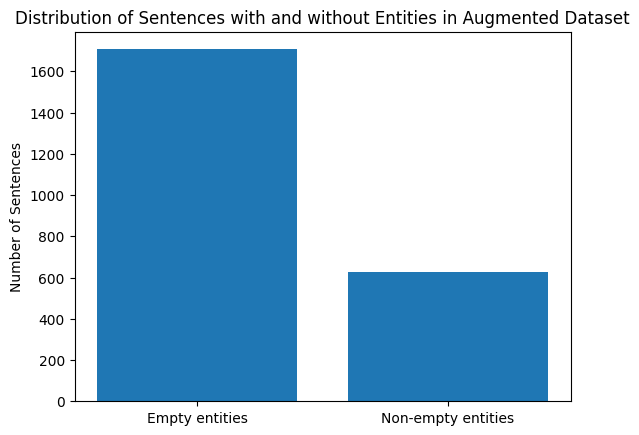

In [210]:
if AUGMENT:
    df_balance = augmented.copy()

    df_balance['output'] = df_balance['output'].replace('', pd.NA)
    
    empty_count = df_balance['output'].isna().sum()
    non_empty_count = (~df_balance['output'].isna()).sum()
    
    plt.bar(
        x=['Empty entities', 'Non-empty entities'],
        height=[empty_count, non_empty_count]
    )
    plt.ylabel('Number of Sentences')
    plt.title('Distribution of Sentences with and without Entities in Augmented Dataset')
    plt.show()

In [218]:
if AUGMENT:
    augmented['output'] = augmented['output'].apply(lambda x: x.split(':')[0] if ':' in str(x) else None)
    augmented.rename(columns={'input':'sentence','output':'term'}, inplace=True)
    augmented['word'] = augmented['sentence'].apply(lambda x: str(x).split())    
    augmented = augmented.explode('word')
    augmented['tag'] = augmented.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
    augmented['word_labels'] = augmented[['sentence', 'tag']].groupby('sentence').transform(lambda x: ','.join(x))
    augmented.drop_duplicates(subset=['sentence'], inplace=True)
    
    augmented.head()

In [219]:
if AUGMENT:
    train_df, eval_df, test_df = split_jsonl_dataset(augmented)
    dataset = plot_term_distribution(train_df, eval_df, test_df, top_n=100)

In [220]:
if AUGMENT:
    train_df.to_csv('data/train_ner_aug.csv',index=False)
    eval_df.to_csv('data/eval_ner_aug.csv',index=False)
    test_df.to_csv('data/test_ner_aug.csv',index=False)

### Augmenting the doctored Data

In [223]:
with open('../preprocessing/additional_examples.json', "r", encoding="utf-8") as f:
    data = json.load(f)

# Extract sentences
sentences = data.get("sentences", [])  # adjust if it's actually "sentences"
additional_examples = pd.DataFrame(sentences)

In [224]:
additional_examples['term'] = additional_examples['output'].apply(lambda x: x.split(':')[0].lower() if ':' in str(x) else None)
additional_examples['output'] = additional_examples['term'].apply(lambda x: str(x).lower() if x is not None else None)
peakless_examples = additional_examples[~additionnal_examples['term'].isin(testing_terms+[t.lower() for t in testing_terms])].reset_index(drop=True)
added_train,added_eval,_ = split_jsonl_dataset(peakless_examples,train_frac=0.75, eval_frac=0.25, test_frac=0, random_state=42)
added_train

,input,output,term
0,"Վերին հարթակում գտնվեց քարե սալ, որի վրա փորագ...",ջրօգտագործման արձանագրություն,ջրօգտագործման արձանագրություն
1,Գմբեթային անցքի տակ պահպանվում է Գմբեթային արձ...,գմբեթային արձանագրություն,գմբեթային արձանագրություն
2,Սրահի աջ անկյունում տեղադրված ցուցատախտակի տակ...,տապանաքարային վիմագիր,տապանաքարային վիմագիր
3,"Վանական կանոնակարգը ամփոփված է Կանոնագիր, որը ...",կանոնագիր,կանոնագիր
4,Ավանդույթների ուսումնասիրողը հրապարակեց հիշատա...,հիշատակագրային վիմագիր,հիշատակագրային վիմագիր
...,...,...,...
395,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,նվիրատվական արձանագրություն
396,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,դամբարանային արձանագրություն
397,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,սյունային արձանագրություն
398,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,օրհնագիր


In [225]:
added_train.drop(columns=['term'], inplace=True)
added_train.rename(columns={'input':'sentence','output':'term'}, inplace=True)
added_train['word'] = added_train['sentence'].apply(lambda x: str(x).split())    
print(added_train.columns)
added_train=  added_train.explode('word')
added_train['tag'] = added_train.apply(lambda x: tag_logic(x['term'], x['word']), axis=1)
added_train['word_labels'] = added_train[['sentence', 'tag']].groupby('sentence').transform(lambda x: ','.join(x))
added_train.drop_duplicates(subset=['sentence'], inplace=True)
added_train

Index(['sentence', 'term', 'word'], dtype='object')


,sentence,term,word,tag,word_labels
0,"Վերին հարթակում գտնվեց քարե սալ, որի վրա փորագ...",ջրօգտագործման արձանագրություն,Վերին,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O"
1,Գմբեթային անցքի տակ պահպանվում է Գմբեթային արձ...,գմբեթային արձանագրություն,Գմբեթային,O,"O,O,O,O,O,O,O,O,O"
2,Սրահի աջ անկյունում տեղադրված ցուցատախտակի տակ...,տապանաքարային վիմագիր,Սրահի,O,"O,O,O,O,O,O,O,O,B-INSC,O,O,O,O"
3,"Վանական կանոնակարգը ամփոփված է Կանոնագիր, որը ...",կանոնագիր,Վանական,O,"O,O,O,O,O,O,O,O,O,O,O,O"
4,Ավանդույթների ուսումնասիրողը հրապարակեց հիշատա...,հիշատակագրային վիմագիր,Ավանդույթների,O,"O,O,O,B-INSC,I-INSC,O,O,O,O,O,O"
...,...,...,...,...,...
395,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,Գավթի,O,"O,O,O,O,O,O,O,O,O"
396,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,Դաշտային,O,"O,O,O,O,O,O,O,O,O,O"
397,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,Սյունաշարի,O,"O,O,O,O,O,O,B-INSC,O,O,O"
398,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,Գրախոսը,O,"O,O,O,O,O,O,O,O,O,O,O"


In [226]:
added_train.term.unique()

array(['ջրօգտագործման արձանագրություն ', 'գմբեթային արձանագրություն ',
       'տապանաքարային վիմագիր ', 'կանոնագիր ', 'հիշատակագրային վիմագիր ',
       'նվիրագիր ', 'վերանորոգման, նորոգման արձանագրություն ',
       'գավիթային արձանագրություն ', 'կոթողային արձանագրություն ',
       'վիմագիր ', 'թագավորական արձանագրություն ',
       'եկեղեցու արձանագրություն ', 'նվիրատվական արձանագրություն ',
       'ապարանքների շինարարական արձանագրություններ ',
       'կառուցողական արձանագրություն ', 'սյունային արձանագրություն ',
       'իշխանական արձանագրություն ', 'դռնագիր ',
       'վանական արձանագրություն ', 'տապանագիր ',
       'մատենագիտական արձանագրություն ', 'դամբարանախուցի մակագրություն ',
       'կանոնաիրավական արձանագրություն ', 'դամբարանային արձանագրություն ',
       'հարկային արձանագրություն ', 'օրհնագիր ',
       'փակագիր արձանագրություն ', 'շրջագիր ծածկագիր ',
       'տապանաքարային արձանագրություն ', 'պետրոգլիֆ ', 'ժայռապատկեր ',
       'վերակառուցման արձանագրություն ', 'ժամատան արձանագրո

```'water use protocol ', 'dome protocol ',
'tombstone epitaph ', 'statute ', 'memorial epitaph ',
'donation epitaph ', 'renovation, renovation protocol ',
'porch protocol ', 'monumental protocol ',
'epitaph ', 'royal protocol ',
'church protocol ', 'donation protocol ',
'building protocols of palaces ',
'constructive protocol ', 'columnar protocol'
```

In [227]:
added_eval.drop(columns=['term'], inplace=True)
added_eval.rename(columns={'input':'sentence','output':'term'}, inplace=True)
added_eval['word']=added_eval['sentence'].apply(lambda x: str(x).split())    
added_eval = added_eval.explode('word')
added_eval['tag'] = added_eval.apply(lambda x: tag_logic(x['term'], x['word']),axis=1)
added_eval['word_labels'] = added_eval[['sentence','tag']].groupby('sentence').transform(lambda x: ','.join(x))
added_eval.drop_duplicates(subset=['sentence'], inplace=True)
added_eval

,sentence,term,word,tag,word_labels
0,Արխիվային տեղեկագրում լուսաբանվեց անհայտ Հուշա...,հուշագիր,Արխիվային,O,"O,O,O,O,O,O,O,O,O"
1,Լեռան լանջին տեղադրված խաչքարի հիմքում կա Հուշ...,հուշագիր,Լեռան,O,"O,O,O,O,O,O,O,O,O,O,O"
2,Տեղում պահպանված վիմական արձանագրություն ցույց...,վիմական արձանագրություն,Տեղում,O,"O,O,B-INSC,I-INSC,O,O,O,O,O,O,O"
3,Հնագետներն արձանագրեցին հիշատակագիր՝ որում նշվ...,հիշատակագիր,Հնագետներն,O,"O,O,O,O,O,O,O,O,O"
4,Արձանագրության գրականության մեջ հաճախ է հիշատա...,խաչքարային արձանագրություն,Արձանագրության,O,"O,O,O,O,O,O,O,O,O,O,O,O"
...,...,...,...,...,...
115,Տեղական համայնքն իր միջոցներով մաքրեց Տաղավարի...,տաղավարի արձանագրություն,Տեղական,O,"O,O,O,O,O,O,O,O,O,O"
116,Դաշտային նոթերում ընդգրկվեց այս գերեզմանատան ա...,գերեզմանատան արձանագրություն,Դաշտային,O,"O,O,O,O,B-INSC,O,O,O,O,O"
117,"Քանդակագործական արհեստանոցում ցույց տրվեց, թե ...",սյունագիր,Քանդակագործական,O,"O,O,O,O,O,O,O,O,O,O,O,O"
118,Մատենադարանի ցուցասրահում ներկայացված հիշատակա...,հիշատակագիր,Մատենադարանի,O,"O,O,O,B-INSC,O,O,O,O,O"


In [228]:
train_aug_doc = pd.concat([train_df_doctored, added_train], ignore_index=True)
eval_aug_doc = pd.concat([eval_df_doctored, added_eval], ignore_index=True)

train_aug_doc.to_csv('data/train_ner_aug_doctored.csv',index=False)
eval_aug_doc.to_csv('data/eval_ner_aug_doctored.csv',index=False)

train_aug_doc

,sentence,term,word,tag,word_labels
0,գիմք ընդունելով ձեռագրում տվյալ միավորի խորագի...,վիմագրերը,գիմք,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,B-IN..."
1,նախորդ հրատարակիչը վիմագրի ծանոթագրության մեջ ...,Վիմագիր,նախորդ,O,"O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,O,..."
2,ոմն առյուծի հայր սխիթար ճոն հիշատակված է նաև ա...,վիմագրերից,ոմն,O,"O,O,O,O,O,O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O..."
3,պրակն ընդգրկում է գհեիրակի մարզի վիմական արձան...,վիմական արձանագրությունները,պրակն,O,"O,O,O,O,O,B-INSC,I-INSC"
4,արևելյան նիրակի ներկայիս հ շիրակի մարզ վիմագիր...,վիմագիր,արևելյան,O,"O,O,O,O,O,O,B-INSC,O,O,O,O,O,O,O,O,O,O,O,O,O,O..."
...,...,...,...,...,...
1602,Գավթի սյան վրա փորագրված է Նվիրատվական արձանագ...,նվիրատվական արձանագրություն,Գավթի,O,"O,O,O,O,O,O,O,O,O"
1603,Դաշտային հեռադիտակով նկատվեց Դամբարանային արձա...,դամբարանային արձանագրություն,Դաշտային,O,"O,O,O,O,O,O,O,O,O,O"
1604,Սյունաշարի կենտրոնական սյան վրա պահպանվել է սյ...,սյունային արձանագրություն,Սյունաշարի,O,"O,O,O,O,O,O,B-INSC,O,O,O"
1605,"Գրախոսը նշել է, որ այս Օրհնագիր եզակի է իր վան...",օրհնագիր,Գրախոսը,O,"O,O,O,O,O,O,O,O,O,O,O"


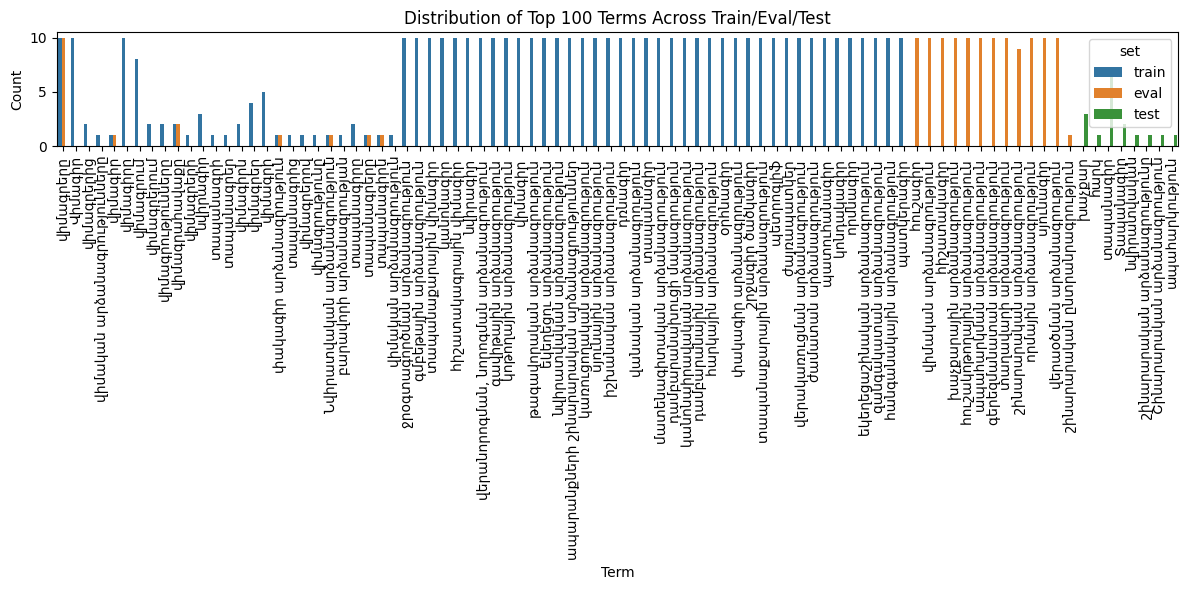

In [229]:
dfp = plot_term_distribution(train_aug_doc, eval_aug_doc, test_df_doctored, top_n=100)

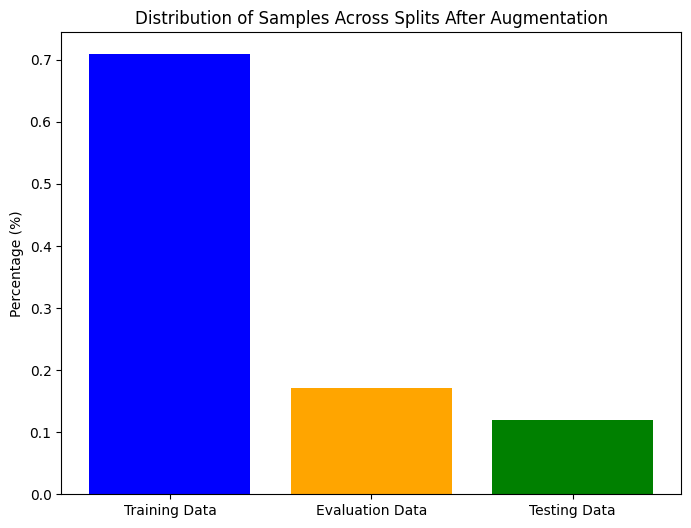

In [230]:
total_aug_len = len(train_aug_doc) + len(eval_aug_doc) + len(test_df_doctored)
relative_aug_len = [len(train_aug_doc)/total_aug_len, len(eval_aug_doc)/total_aug_len, len(test_df_doctored)/total_aug_len]
labels = ['Training Data', 'Evaluation Data', 'Testing Data']
plt.figure(figsize=(8,6))
plt.bar(labels, relative_aug_len, color=['blue', 'orange', 'green'])
plt.ylabel('Percentage (%)')
plt.title('Distribution of Samples Across Splits After Augmentation')
plt.show()


In [231]:
test_df_doctored.term.unique()

array(['խաչքար', 'հարկ', 'տապանագիր', 'Տապանագիր', 'նվիրատվական',
       'շինարարական արձանագրությունը', 'Շինարարական արձանագրություն',
       'ապահարկություն', None], dtype=object)